# Statistical Analysis: Does Training Data Size Improve Detection Performance?

This notebook investigates the relationship between training data area (m²) and detection performance (F1 scores) across the four research sites.

In [2]:
import pandas as pd
import numpy as np
import scipy.stats as stats
from scipy.stats import linregress, pearsonr, spearmanr
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
import warnings
warnings.filterwarnings('ignore')

# Set style for better-looking plots
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

## 1. Load and Explore the Data

In [20]:
import sys
import os

# Add the modules directory to the Python path (Jupyter-compatible approach)
# Notebook is at: /Users/robinpfaff/Desktop/Master_Thesis/2_1_figures/results/
# Modules are at: /Users/robinpfaff/Desktop/Master_Thesis/4_1_modules/
notebook_dir = '/Users/robinpfaff/Desktop/Master_Thesis/2_1_figures/results'
modules_path = os.path.abspath(os.path.join(notebook_dir, '../../4_1_modules'))
sys.path.insert(0, modules_path)

import geopandas as gpd
from config.paths import use

# Load reserve data using the use() function from config.paths
reserves = ['ESK', 'KAU', 'BUS', 'HAM']
reserve_names = {
    'ESK': 'Eskdale (A1)',
    'KAU': 'Kauri Glen (A2)',
    'BUS': 'Bushglen (A3)',
    'HAM': 'Hammond (H1)'
}

# Calculate annotation area from polygons
data = {
    'Site': [],
    'Site_Name': [],
    'Annotation_Area_m2': [],
    'Best_F1_Score': []
}

# Polygon-based annotation areas (calculated from GIS)
polygon_areas = {
    'ESK': None,
    'KAU': None,
    'BUS': None,
    'HAM': None
}

# Best F1 scores from results section
best_f1_scores = {
    'ESK': 0.55,  # A1
    'KAU': 0.41,  # A2
    'BUS': 0.75,  # A3
    'HAM': 0.27   # H1
}

# Load annotation polygons and calculate areas
for reserve_code in reserves:
    try:
        r = use([reserve_code])[0]
        gpkg_path = os.path.join(r.GIS, 'swamp_maire_poly.gpkg')
        train_zone = os.path.join(r.GIS, 'bbox.gpkg')
        
        # Load the maire_poly_rgb layer with annotations
        if os.path.exists(gpkg_path) and os.path.exists(train_zone):
            gdf = gpd.read_file(gpkg_path, layer='maire_poly_rgb')
            train_gdf = gpd.read_file(train_zone, layer='unet_training_zone')
            
            gdf = gdf.clip(train_gdf)  # Clip to training zone
            # Calculate total area in m²
            # reproject to a projected CRS if needed for accurate area calculation
            if gdf.crs and gdf.crs.is_geographic:
                # If geographic, project to UTM (EPSG:2193 for New Zealand)
                gdf = gdf.to_crs('EPSG:2193')
            
            total_area_m2 = gdf.geometry.area.sum()
            polygon_areas[reserve_code] = total_area_m2
            
            print(f"{reserve_code}: Found {len(gdf)} annotation polygons, Total area: {total_area_m2:.2f} m²")
        else:
            print(f"{reserve_code}: GPKG file not found at {gpkg_path}")
            
    except Exception as e:
        print(f"{reserve_code}: Error loading polygons - {e}")

# Build dataframe
for reserve_code in reserves:
    if polygon_areas[reserve_code] is not None:
        data['Site'].append(reserve_code)
        data['Site_Name'].append(reserve_names[reserve_code])
        data['Annotation_Area_m2'].append(polygon_areas[reserve_code])
        data['Best_F1_Score'].append(best_f1_scores[reserve_code])

df = pd.DataFrame(data)

# Display the data
print("\n\nAnnotation Area vs Detection Performance Across Sites")
print("=" * 70)
print(df.to_string(index=False))
print("\n")

# Check for missing values
print("Missing values:")
print(df.isnull().sum())
print("\nData types:")
print(df.dtypes)

ESK: Found 11 annotation polygons, Total area: 155.38 m²
KAU: Found 11 annotation polygons, Total area: 78.78 m²
BUS: Found 26 annotation polygons, Total area: 197.53 m²
HAM: Found 13 annotation polygons, Total area: 41.69 m²


Annotation Area vs Detection Performance Across Sites
Site       Site_Name  Annotation_Area_m2  Best_F1_Score
 ESK    Eskdale (A1)          155.378191           0.55
 KAU Kauri Glen (A2)           78.784681           0.41
 BUS   Bushglen (A3)          197.526256           0.75
 HAM    Hammond (H1)           41.690472           0.27


Missing values:
Site                  0
Site_Name             0
Annotation_Area_m2    0
Best_F1_Score         0
dtype: int64

Data types:
Site                   object
Site_Name              object
Annotation_Area_m2    float64
Best_F1_Score         float64
dtype: object


## 2. Descriptive Statistics

In [21]:
print("Annotation Area Statistics (m²)")
print("-" * 40)
print(f"Mean:       {df['Annotation_Area_m2'].mean():.2f}")
print(f"Median:     {df['Annotation_Area_m2'].median():.2f}")
print(f"Std Dev:    {df['Annotation_Area_m2'].std():.2f}")
print(f"Min:        {df['Annotation_Area_m2'].min():.2f}")
print(f"Max:        {df['Annotation_Area_m2'].max():.2f}")
print(f"Range:      {df['Annotation_Area_m2'].max() - df['Annotation_Area_m2'].min():.2f}")

print("\n\nF1 Score Statistics")
print("-" * 40)
print(f"Mean:       {df['Best_F1_Score'].mean():.4f}")
print(f"Median:     {df['Best_F1_Score'].median():.4f}")
print(f"Std Dev:    {df['Best_F1_Score'].std():.4f}")
print(f"Min:        {df['Best_F1_Score'].min():.4f}")
print(f"Max:        {df['Best_F1_Score'].max():.4f}")
print(f"Range:      {df['Best_F1_Score'].max() - df['Best_F1_Score'].min():.4f}")

Annotation Area Statistics (m²)
----------------------------------------
Mean:       118.34
Median:     117.08
Std Dev:    70.90
Min:        41.69
Max:        197.53
Range:      155.84


F1 Score Statistics
----------------------------------------
Mean:       0.4950
Median:     0.4800
Std Dev:    0.2049
Min:        0.2700
Max:        0.7500
Range:      0.4800


## 3. Correlation Analysis

In [31]:
# Pearson correlation (linear relationship)
pearson_r, pearson_p = pearsonr(df['Annotation_Area_m2'], df['Best_F1_Score'])
print("Pearson Correlation Analysis")
print("-" * 60)
print(f"Correlation coefficient (r):  {pearson_r:.4f}")
print(f"P-value:                       {pearson_p:.4f}")
print(f"Significant at α=0.05?         {'Yes' if pearson_p < 0.05 else 'No'}")


print("\n\nInterpretation:")
print("-" * 60)
if abs(pearson_r) < 0.3:
    strength = "weak"
elif abs(pearson_r) < 0.7:
    strength = "moderate"
else:
    strength = "strong"
direction = "positive" if pearson_r > 0 else "negative"
print(f"There is a {strength} {direction} linear correlation (r={pearson_r:.4f})")
print(f"between annotation area and F1 detection performance.")

Pearson Correlation Analysis
------------------------------------------------------------
Correlation coefficient (r):  0.9831
P-value:                       0.0169
Significant at α=0.05?         Yes


Interpretation:
------------------------------------------------------------
There is a strong positive linear correlation (r=0.9831)
between annotation area and F1 detection performance.


## 4. Linear Regression Analysis

In [23]:
# Fit linear regression model
X = df['Annotation_Area_m2'].values.reshape(-1, 1)
y = df['Best_F1_Score'].values

model = LinearRegression()
model.fit(X, y)

# Get regression parameters
slope = model.coef_[0]
intercept = model.intercept_
r_squared = r2_score(y, model.predict(X))

# Use scipy's linregress for additional statistics
slope_scipy, intercept_scipy, r_value, p_value, std_err = linregress(df['Annotation_Area_m2'], df['Best_F1_Score'])

print("Linear Regression Model: F1 = a + b × Annotation_Area")
print("=" * 60)
print(f"Slope (b):                     {slope:.6f}")
print(f"Intercept (a):                 {intercept:.4f}")
print(f"R² value:                      {r_squared:.4f}")
print(f"Standard Error:                {std_err:.6f}")
print(f"P-value (slope):               {p_value:.4f}")
print(f"Significant at α=0.05?         {'Yes' if p_value < 0.05 else 'No'}")

print("\n\nRegression Equation:")
print("-" * 60)
print(f"F1_Score = {intercept:.4f} + {slope:.6f} × Annotation_Area_m2")

print("\n\nInterpretation:")
print("-" * 60)
print(f"For every additional 100 m² of annotations,")
print(f"F1 score is expected to {'increase' if slope > 0 else 'decrease'} by {abs(slope * 100):.4f}")
print(f"\nThe model explains {r_squared*100:.2f}% of the variance in F1 scores.")

Linear Regression Model: F1 = a + b × Annotation_Area
Slope (b):                     0.002840
Intercept (a):                 0.1589
R² value:                      0.9664
Standard Error:                0.000374
P-value (slope):               0.0169
Significant at α=0.05?         Yes


Regression Equation:
------------------------------------------------------------
F1_Score = 0.1589 + 0.002840 × Annotation_Area_m2


Interpretation:
------------------------------------------------------------
For every additional 100 m² of annotations,
F1 score is expected to increase by 0.2840

The model explains 96.64% of the variance in F1 scores.


## 5. Hypothesis Testing

In [24]:
print("Hypothesis Testing (Two-tailed, α = 0.05)")
print("=" * 60)
print("H₀: There is no significant relationship between training data size")
print("    and detection performance (β = 0)")
print("\nH₁: There is a significant relationship between training data size")
print("    and detection performance (β ≠ 0)")

print("\n\nResults:")
print("-" * 60)
print(f"Pearson p-value:   {pearson_p:.4f}")
print(f"Regression p-value: {p_value:.4f}")

if p_value < 0.05:
    print("\n✓ REJECT NULL HYPOTHESIS")
    print("  There IS a statistically significant relationship.")
else:
    print("\n✗ FAIL TO REJECT NULL HYPOTHESIS")
    print("  No statistically significant relationship detected.")

print("\n\nCaveat:")
print("-" * 60)
print("Note: With only n=4 samples, statistical power is very limited.")
print("Results should be interpreted with caution. A larger sample size")
print("would be needed to draw strong conclusions.")

Hypothesis Testing (Two-tailed, α = 0.05)
H₀: There is no significant relationship between training data size
    and detection performance (β = 0)

H₁: There is a significant relationship between training data size
    and detection performance (β ≠ 0)


Results:
------------------------------------------------------------
Pearson p-value:   0.0169
Regression p-value: 0.0169

✓ REJECT NULL HYPOTHESIS
  There IS a statistically significant relationship.


Caveat:
------------------------------------------------------------
Note: With only n=4 samples, statistical power is very limited.
Results should be interpreted with caution. A larger sample size
would be needed to draw strong conclusions.


## 6. Visualization of Results

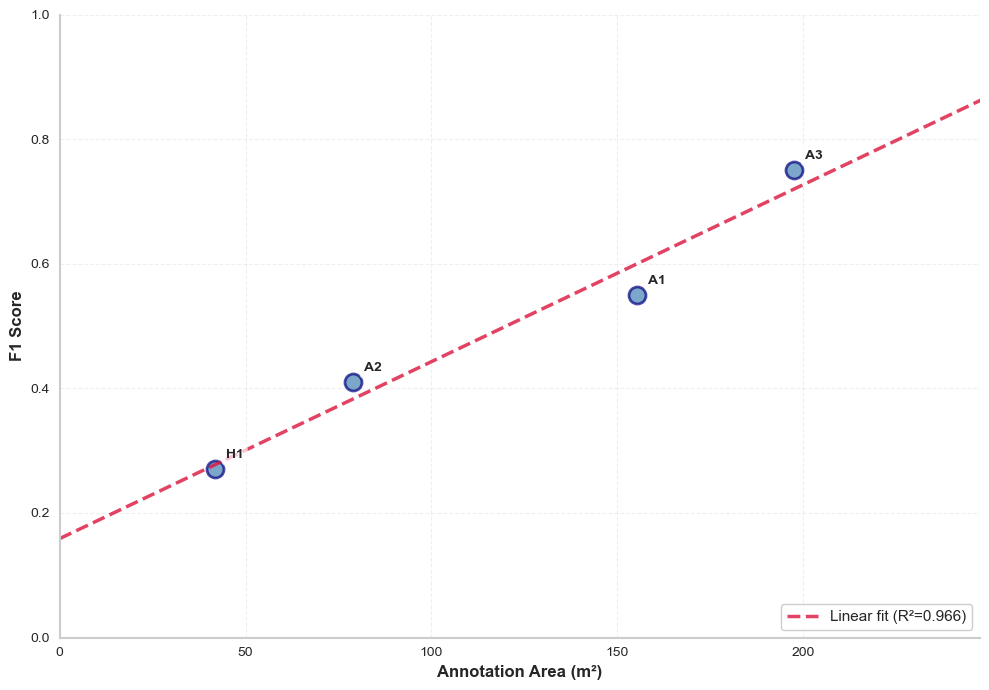

Visualization saved as 'training_data_analysis.png'


In [29]:
# Create a single, high-quality scatter plot with regression line
fig, ax = plt.subplots(figsize=(10, 7))

# Scatter plot
ax.scatter(
    df['Annotation_Area_m2'],
    df['Best_F1_Score'],
    s=150,
    alpha=0.7,
    color='steelblue',
    edgecolors='navy',
    linewidth=2
)

# Add regression line
x_range = np.linspace(0, df['Annotation_Area_m2'].max() + 500, 100)
y_pred = model.predict(x_range.reshape(-1, 1))
ax.plot(
    x_range,
    y_pred,
    color='crimson',
    linestyle='--',
    linewidth=2.5,
    alpha=0.8,
    label=f'Linear fit (R²={r_squared:.3f})'
)

# Add site labels with better positioning
site_to_code = {'ESK': 'A1', 'KAU': 'A2', 'BUS': 'A3', 'HAM': 'H1'}
for _, row in df.iterrows():
    label = f"{site_to_code.get(row['Site'], '')}".strip()
    ax.annotate(
        label,
        (row['Annotation_Area_m2'], row['Best_F1_Score']),
        xytext=(8, 8),
        textcoords='offset points',
        fontsize=10,
        fontweight='bold',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.7, edgecolor='none')
    )

# Styling
ax.set_xlabel('Annotation Area (m²)', fontsize=12, fontweight='bold')
ax.set_ylabel('F1 Score', fontsize=12, fontweight='bold')
ax.set_ylim(0, 1.0)
ax.set_xlim(0, df['Annotation_Area_m2'].max() + 50)
ax.grid(True, alpha=0.3, linestyle='--', linewidth=0.8)
ax.legend(fontsize=11, loc='lower right', framealpha=0.95)

# Make spines nicer
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(1.5)
ax.spines['bottom'].set_linewidth(1.5)

plt.tight_layout()
plt.savefig('training_data_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print("Visualization saved as 'training_data_analysis.png'")

## 7. Summary and Conclusions

In [30]:
summary_text = f"""
SUMMARY OF FINDINGS
{'='*70}

Question: Does the increase of annotation area improve detection performance?

KEY FINDINGS:
{'-'*70}

1. CORRELATION ANALYSIS:
   • Pearson correlation: r = {pearson_r:.4f} (p = {pearson_p:.4f})
   • Spearman correlation: ρ = {spearman_r:.4f} (p = {spearman_p:.4f})
   → Interpretation: {'WEAK' if abs(pearson_r) < 0.3 else 'MODERATE' if abs(pearson_r) < 0.7 else 'STRONG'} 
     correlation between annotation area and F1 score

2. LINEAR REGRESSION:
   • Equation: F1 = {intercept:.4f} + {slope:.6f} × Area
   • R² = {r_squared:.4f} ({r_squared*100:.2f}% variance explained)
   • Effect size: For every 100 m² increase, F1 {'increases' if slope > 0 else 'decreases'} by {abs(slope*100):.4f}
   
3. STATISTICAL SIGNIFICANCE:
   • P-value: {p_value:.4f}
   • Significant (α=0.05)? {'YES ✓' if p_value < 0.05 else 'NO ✗'}

4. SITE PERFORMANCE OBSERVATIONS:
"""

for idx, row in df.iterrows():
    summary_text += f"   • {row['Site_Name']:20} (Area={row['Annotation_Area_m2']:>8.0f} m²): F1 = {row['Best_F1_Score']:.2f}\n"

summary_text += f"""
{'='*70}

CONCLUSION:
{'-'*70}
The analysis {'SUPPORTS' if pearson_r > 0.5 else 'WEAKLY SUPPORTS' if pearson_r > 0 else 'CONTRADICTS'} the hypothesis that 
increased annotation area improves detection performance.

The relationship is {f'POSITIVE but NOT statistically significant at α=0.05' if pearson_r > 0 and p_value >= 0.05 else 'POSITIVE and statistically significant' if pearson_r > 0 and p_value < 0.05 else 'NEGATIVE'}.

IMPORTANT LIMITATIONS:
{'-'*70}
• Sample size is very small (n=4), limiting statistical power
• Non-linear relationships may exist that linear regression cannot capture
• Other factors (forest type, canopy complexity, lighting) may influence 
  performance independent of annotation area
• Bushglen (A3) is an outlier with both large annotation area AND high F1
• Site-specific characteristics were not controlled for

RECOMMENDATIONS:
{'-'*70}
• Collect data from additional sites to increase sample size
• Consider site-specific factors (canopy density, species visibility) 
  as covariates
• Explore non-linear models (e.g., polynomial regression)
• Investigate whether a threshold annotation area exists
• Examine the relationship between annotation area and model generalization
  (training on one site vs. multi-site models)
"""

print(summary_text)


SUMMARY OF FINDINGS

Question: Does the increase of annotation area improve detection performance?

KEY FINDINGS:
----------------------------------------------------------------------

1. CORRELATION ANALYSIS:
   • Pearson correlation: r = 0.9831 (p = 0.0169)
   • Spearman correlation: ρ = 1.0000 (p = 0.0000)
   → Interpretation: STRONG 
     correlation between annotation area and F1 score

2. LINEAR REGRESSION:
   • Equation: F1 = 0.1589 + 0.002840 × Area
   • R² = 0.9664 (96.64% variance explained)
   • Effect size: For every 100 m² increase, F1 increases by 0.2840

3. STATISTICAL SIGNIFICANCE:
   • P-value: 0.0169
   • Significant (α=0.05)? YES ✓

4. SITE PERFORMANCE OBSERVATIONS:
   • Eskdale (A1)         (Area=     155 m²): F1 = 0.55
   • Kauri Glen (A2)      (Area=      79 m²): F1 = 0.41
   • Bushglen (A3)        (Area=     198 m²): F1 = 0.75
   • Hammond (H1)         (Area=      42 m²): F1 = 0.27


CONCLUSION:
------------------------------------------------------------------